## Packages and functions

In [1]:
# CIL imports
from cil.framework import ImageGeometry, AcquisitionGeometry, BlockDataContainer, ImageData

# From cil.plugins import TomoPhantom
from phantominator import shepp_logan

from cil.optimisation.algorithms import FISTA

from cil.plugins.ccpi_regularisation.functions import FGP_TV

from cil.optimisation.functions import LeastSquares, BlockFunction, L2NormSquared, IndicatorBox
from cil.optimisation.utilities import callbacks

# For display
from cil.utilities.display import show2D, show1D, show_geometry

# ASTRA imports
from cil.plugins.astra.operators import ProjectionOperator

from cil.optimisation.algorithms import CGLS, GD

# External imports
import numpy as np
import matplotlib.pyplot as plt
import logging

from cil.optimisation.operators import BlockOperator, DiagonalOperator, GradientOperator, \
                                        CompositionOperator, ZeroOperator, MaskOperator

import time

In [2]:
# functions for preconditioner
def mean_ATA(A, n_pixels):
    """
    A is a ProjectionOperator
    """
    two_norm = L2NormSquared()
    get_ig = A.domain_geometry()

    sum = 0
    for k in range(3):

        # generate random entries
        xk = np.random.normal(0, 1, (n_pixels, n_pixels))

        # put random entries in class <DataContainer>
        xk_datacon = get_ig.allocate()
        xk_datacon.fill(xk)

        # compute 
        yk = A.direct(xk_datacon)
        sum += two_norm(yk)
    
    final = (1/3)*sum
    return final

def create_abs(A, weights, n):
    """
    weights in np array from np.shape(weights) = n_pixels X n_pixels

    n: number of pixels
    """
    weights_arr = weights.as_array()

    a_1 = weights_arr.flatten()
    a_2 = weights_arr.flatten()

    pix_squared = len(a_1)
    for i in range(pix_squared - 1):
        a_1[i] += a_1[i+1]

    for i in range(pix_squared - n):
        a_2[i] += a_2[i + n]
    
    ATAI_mean = mean_ATA(A, n)

    a = a_1 + a_2 + ATAI_mean

    b = (-weights_arr.flatten())[1:]
    c = (-weights_arr.flatten())[n:]
    return a, b, c

def solve_Ux(diag, updiag, offdiag, y):
    """
   diag has length N, then off diag has lenth N-n and is put appropiatly in the matrix system

    Solves Ux = y
    """
    N_big = len(diag)
    n = int(np.sqrt(N_big))

    x = np.zeros(N_big)
    x[-1] = y[-1] / diag[-1]    # setting x[N_big - 1]

    for i in range(2, N_big + 1):   # i loops 2, 3, 4, 5, 6
        k = N_big - i
        if k >= N_big - n:   # N_big - i loops 
            print("first if", N_big - i)
            x[k] = (1 / diag[k]) * (y[k] - updiag[k]*x[k + 1])
        if k < N_big - n:
            print("second if", N_big - i)
            x[k] = (1 / diag[k]) * (y[k] - updiag[k]*x[k + 1] - offdiag[k] * x[k + n])
    return x

def solve_Lx(lowdiag, offdiag, y):
    
    N_big = len(y)
    n = int(np.sqrt(N_big))
    x = np.zeros(N_big)

    print(x[0], y[0])
    x[0] = y[0]
    for i in range(1, N_big):
        if i < n:
            x[i] = y[i] - lowdiag[i - 1]*x[i - 1]
        if i >= n:
            x[i] = y[i] - lowdiag[i - 1]*x[i - 1] - offdiag[i - n]*x[i - n]

    return x

def solve_Pxy(P_a, P_b, P_c, y, ig):
    
    """
    solves Px = y

    P_a, P_b, P_c are defined as in the article figure (41)

    x: returned in np array form
    y: ImageData
    """

    L_lowdiag = P_b / P_a[:-1]
    L_offdiag = P_c / P_a[:len(P_c)]

    y_array = y.as_array()
    y_flat = y_array.flatten()

    temp_solve = solve_Lx(L_lowdiag, L_offdiag, y_flat)
    x = solve_Ux(P_a, P_b, P_c, temp_solve)

    result = ig.allocate()
    result.fill(x)

    return result

In [3]:
# functions to set A, ig, ag, phantom, etc.

def get_A(n_angles, n_pixels):

    # Angles
    angles = np.linspace(0, 180, n_angles, endpoint=False, dtype=np.float32)

    # Setup acquisition geometry

    # Note that if number of pixels and number of angels are equal, 
    # the matrix is square and an exact solution can be found, 
    # then there is a sufficient number of pojections
    ag = AcquisitionGeometry.create_Parallel2D()\
                                .set_angles(angles)\
                                .set_panel(n_pixels, pixel_size=1/n_pixels)

    # Setup image geometry
    ig = ImageGeometry(voxel_num_x=n_pixels, 
                    voxel_num_y=n_pixels, 
                    voxel_size_x=1/n_pixels, 
                    voxel_size_y=1/n_pixels)
    
    A = ProjectionOperator(ig, ag, device='cpu')

    # Get phantom
    phantom = ImageData(np.flip(shepp_logan(n_pixels)), geometry = ig)

    # Create an acquisition data (numerically)
    sino = A.direct(phantom)

    return A, sino, ig, ag, phantom

def add_poss_noise(background_counts, n_angles, n_pixels):
    A, sino, ig, ag, phantom = get_A(n_angles, n_pixels)

    # adding noise to the sinogram

    # Convert the simulated absorption sinogram to transmission values using Lambert-Beer. 
    counts_poss = background_counts * np.exp(-sino.as_array())

    # Use as a mean for Poisson data generation.
    noisy_counts_poss = np.random.poisson(counts_poss)
    nonzero = noisy_counts_poss > 0

    # Convert back to absorption sinogram.
    sino_out_poss = np.zeros_like(sino.as_array())
    sino_out_poss[nonzero] = -np.log(noisy_counts_poss[nonzero]/ background_counts)

    # allocate sino_noisy and fill with noisy data
    sino_noisy_poss = ag.allocate()
    sino_noisy_poss.fill(sino_out_poss)

    return sino_noisy_poss

In [4]:
## functions using build in CGLS function from CIL

def onenorm_cgls(initial, inner_iter, outer_iter, A, sino, alpha, er, cg_tol, exact):

    """
    Function that minimises the cost function 

    J(u) = ||Ru - b||_2^2 + ||u||_1

    by minimising 

    J(u) = ||Ru - b||_2^2 + ||W_k u||_2^2

    via the BlockFramework and the cgls function from CIL. the matrix W_k is reweighted in each iteration
    with W_k = u_k**(-1/2)

    Input
        Initial:    initial guess for u (ImageData)
        inner_iter: maximum number of iterations for cgls (integer)
        outer_iter: maximum number of iterations to reweight W_k (integer)
        A:          operator R (ProjectionOperator)
        sino:       lhs of the data fidelity term, 'b' (ImageData)
        alpha:      regularisation parameter (float)
        er:         lower bound for values in W_k to be considered to reweight, 
                    low values will be set to zero (float)
        cg_tol:     tolerance for cg (float)
        exact:      if known, the exact solution to the reconstruction problem (ImageData), 
                    if not known, put None and the backward error is computed

    Output
        uk:         reconstructed image (ImageData)
        err:        backward error or forward error depending on what is inputted in 'exact' (numpy array)
    """

    uk = initial.copy()
    get_ig = A.domain_geometry()

    if er is None:
        er_use = 0.01 * sino.max()
    else:
        er_use = er

    err = []
    norm = L2NormSquared()
    norm_b = norm(sino)

    if exact == None:
        err_temp = norm(A.direct(uk) - sino) / norm_b
        err.append(err_temp)
    else:
        err_temp = norm(uk - exact)
        err.append(err_temp)

    for k in range(outer_iter):

        print("Outer iteration:", k + 1)
        
        ## reweight the regularisation term ##
        
        uk_grad = uk.abs()
        uk_grad_np = uk_grad.as_array()

        # distinguish 'large' values from 'small' values
        large_values = uk_grad > er_use # ImageData boolean array

        # reweight large values
        uk_reweighted_np = np.zeros_like(uk.as_array()) # small terms are automatically put to zero
        uk_reweighted_np[large_values] = 2**(1/2)*(uk_grad_np[large_values] ** (-1/2))

        # convert back to ImageData
        uk_reweighted = get_ig.allocate()   
        uk_reweighted.fill(uk_reweighted_np)

        ## setting up minimisation functional in BlockFramework ##

        # set W
        w_operator = DiagonalOperator(uk_reweighted)

        # create block operator
        operator_block = BlockOperator(A, np.sqrt(alpha)*w_operator)

        # create block data container
        zero_block = w_operator.range.allocate(0)
        data_block = BlockDataContainer(sino, zero_block)

        # solver inner minimization problem 
        cgls = CGLS(initial=uk, operator=operator_block, data=data_block, update_objective_interval=1)

        # CGLS EarlyStopping terminates CG when ||..._k|| < epsilon*||..._0||
        cgls.run(inner_iter, verbose=0, callbacks=[callbacks.ProgressCallback(), 
                                                   callbacks.CGLSEarlyStopping(epsilon=cg_tol)])
        uk = cgls.solution
        Auk_min_sino = A.direct(uk) - sino

        if exact == None:
            err_temp = norm(Auk_min_sino) / norm_b
            err.append(err_temp)
        else:
            err_temp = norm(uk - exact)
            err.append(err_temp)

        if er is None:
            e = (Auk_min_sino).abs()
            er_use = 0.01 * e.max()
        else:
            er_use = er

    return uk, err

def tv_cgls(initial, inner_iter, outer_iter, A, sino, alpha, er, cg_tol, exact):
    uk = initial.copy()

    # functions that don't depend on iteration for reweighting regularisation term
    get_ig = A.domain_geometry()
    gradient_operator = GradientOperator(get_ig)   # function that computes D_x, D_y

    norm = L2NormSquared()
    norm_b = norm(sino)
    err = []

    if exact == None:
        err_temp = norm(A.direct(uk) - sino) / norm_b
        err.append(err_temp)
    else:
        err_temp = norm(uk - exact)
        err.append(err_temp)

    if er is None:
        er_use = 0.01 * sino.max()
    else:
        er_use = er

    for k in range(outer_iter):
        
        # creating the weights matrix W^{1/2}
        grad = gradient_operator.direct(uk)
        uk_grad = grad[0]**2 + grad[1]**2
        uk_grad_np = uk_grad.as_array()

        # distinguish 'large' values from 'small' values
        large_values = uk_grad > er_use # ImageData boolean array

        # reweight large values
        uk_reweighted_np = np.zeros_like(uk.as_array()) # small terms are automatically put to zero
        uk_reweighted_np[large_values] = 2**(1/2)*(uk_grad_np[large_values] ** (-1/4))

        # convert back to ImageData
        uk_reweighted = get_ig.allocate()   
        uk_reweighted.fill(uk_reweighted_np)

        W_diagonal = DiagonalOperator(uk_reweighted)

        # creating zero operator blocks
        zero_operator = ZeroOperator(get_ig)

        # reg_operator = [W^{1/2}D_x W^{1/2}D_y]^T
        w_matrix = BlockOperator(W_diagonal, zero_operator, W_diagonal, zero_operator, shape=(2,2))
        reg_operator = CompositionOperator(w_matrix, gradient_operator)

        # create block operator
        operator_block = BlockOperator(A, np.sqrt(alpha)*reg_operator)

        # create block data container
        zero_block = reg_operator.range.allocate(0)
        data_block = BlockDataContainer(sino, zero_block)

        # solver inner minimization problem 
        cgls = CGLS(initial=uk, operator=operator_block, data=data_block, update_objective_interval=1)

        cgls.run(inner_iter, verbose=0, callbacks=[callbacks.CGLSEarlyStopping(cg_tol)])

        uk = cgls.solution

        Auk_min_sino = A.direct(uk) - sino

        if exact == None:
            err_temp = norm(Auk_min_sino) / norm_b
            err.append(err_temp)
        else:
            err_temp = norm(uk - exact)
            err.append(err_temp)

        if er is None:
            e = (Auk_min_sino).abs()
            er_use = 0.01 * e.max()
        else:
            er_use = er

    return uk, err

## functions using handmade CG function 

# implementation of CG
def CG(initial, max_iter, A, ATb, alpha, Wk, cg_tol, apply_operator):

    """
    Solves for u in the system 

    apply_operator(u) = A^Tb (*)

    using Conjugate Gradient (CG)

    INPUT:
        initial:    Inital guess for u (ImageData)
        max_iter:   Maximum number of cg iterations (float)
        A:          ProjectionOperator necessary for 'apply_operator' function
        ATb:        A^Tb (ImageData)
        alpha:      Regularisation parameter (float)
        Wk:         Weights in the kth iteration, necessary for `apply_operator' function (ImageData)
        cg_tol:     Tolerance on CG (float)
        apply_operator: Function that applies matrix from normal equation
    
    OUTPUT:
        uk:     Minimiser of (*) (ImageData)
        conv_arr:     Array with residuals from each iteration (numpy array)
        inner_iter_count:   Number of inner iterations used (float)
    """

    u0 = initial.copy()
    r0 = ATb - apply_operator(x=u0, W=Wk, A=A, alpha=alpha)
    p0 = r0
    
    # set initials, note these are all of class <ImageData> 
    pk = p0
    uk = u0
    rk = r0
    delta_new = rk.dot(rk.conjugate())

    # needed for stopping criteria later
    norm = L2NormSquared()
    r0_norm = norm(r0)
    cg_tol *= 2
    rel_tol = r0_norm * cg_tol

    # to check convergence
    conv_arr = []
    conv_arr.append(r0_norm)

    # counting inner iterations
    inner_iter_count = max_iter

    # perform CG iterations
    for k in range(max_iter):

        # zk = Apk
        zk = apply_operator(x=pk, W=Wk, A=A, alpha=alpha)

        alpha_k = delta_new/(pk.dot(zk.conjugate()))
        
        uk_plus_one = uk + alpha_k * pk 
        rk_plus_one = rk - alpha_k * zk

        delta_old = delta_new
        delta_new = rk_plus_one.dot(rk_plus_one.conjugate())

        beta_k = delta_new/delta_old

        pk_plus_one = rk_plus_one + beta_k * pk

        # stopping criteria
        check = norm(rk_plus_one)
        conv_arr.append(check)
        if check < rel_tol:
            uk = uk_plus_one
            inner_iter_count = k + 1
            print(f"cg converged in {k+1} iterations")
            break

        # reset variables
        rk = rk_plus_one
        pk = pk_plus_one
        uk = uk_plus_one

    return uk, conv_arr, inner_iter_count

# lasso regularisation 

def apply_operator_onenorm(x, W, A, alpha):

    """
    Applies the operator 
    
    A^TA + alpha * W 
    
    to the input ImageData x. Used to solve the normal equations 

    (R^TR + alpha * W_k)u = R^Ty

    with W_k = u_k**(-1)

    Input:
        x:  ImageData to which the operator is applied
        W:  Weights
        alpha:  regularisation parameter

    Output:
        z: ImageData (A^TA + alpha * W)x
    """
    
    # z2 = (A^TA)x
    z1 = A.direct(x)
    z2 = A.adjoint(z1)

    # z3 = Wx
    w_operator = DiagonalOperator(W)
    z3 = w_operator.direct(x)

    z = z2 + alpha * z3

    return z

def onenorm_normal(initial, inner_iter, outer_iter, A, sino, alpha, er, cg_tol, exact):
    """
    Finds a solution for the problem 

    ||Au - b||_2^2 + alpha * ||u||_1

    by first rewriting the regularisation term into a two norm by a weights matrix W and then solving via
    the normal equations using CG. The normal equations are given by 

    (A^TA + alpha*W_k)u = A^Tb

    In each outer iterations the matrix W_k is updated (reweighted), W_k = u_k^(-1)

    Input:
        initial:    Initial guess for u (ImageData)
        inner_iter: Number of CG iterations (scalar)
        outer_iter: Number of outer iterations (scalar)
        A:          The acting operator (Operator)
        sino:       The obtained data (AcquisitionData)
        alpha:      Regularization parameter (scalar)
        er:         Upper bound for 'small values' in W_k that will be set to zero (float)

    Output:
        uk:         Reconstructed image (ImageData)
    """

    # setting up LHS of normal equation
    lhs = A.adjoint(sino)

    # setting initials
    uk = initial.copy()
    get_ig = A.domain_geometry()

    norm = L2NormSquared()
    norm_b = norm(sino)
    err = []

    inner_itercount_arr = []

    if exact == None:
        err_temp = norm(A.direct(uk) - sino) / norm_b
        err.append(err_temp)
    else:
        err_temp = norm(uk - exact)
        err.append(err_temp)

    if er is None:
        er_use = 0.01 * sino.max()
    else:
        er_use = er

    for k in range(outer_iter):

        print(f"outer iteration: {k+1}")
        
        ## reweight the regularisation term ##
        uk_grad = uk.abs()
        uk_grad_np = uk_grad.as_array()

        # distinguish 'large' values from 'small' values
        large_values = uk_grad > er_use # ImageData boolean array

        # reweight large values
        uk_reweighted_np = np.zeros_like(uk.as_array()) # small terms are automatically put to zero
        uk_reweighted_np[large_values] = 2*(uk_grad_np[large_values] ** (-1))

        # convert back to ImageData
        uk_reweighted = get_ig.allocate()   
        uk_reweighted.fill(uk_reweighted_np)

        # performing CG
        cg_output, conv_arr, inner_iter_count = CG(uk, inner_iter, A, lhs, alpha, uk_reweighted, cg_tol, apply_operator_onenorm)
        inner_itercount_arr.append(inner_iter_count)

        uk = cg_output
        Auk_min_sino = A.direct(uk) - sino

        if exact == None:
            err_temp = norm(Auk_min_sino) / norm_b
            err.append(err_temp)
        else:
            err_temp = norm(uk - exact)
            err.append(err_temp)

        if er is None:
            e = (Auk_min_sino).abs()
            er_use = 0.01 * e.max()
        else:
            er_use = er

    return uk, err, conv_arr, inner_itercount_arr

# tv regularisation 

def apply_operator_tv(x, W, A, alpha):

    
    """
    Applies the operator 
    
    A^TA + alpha *D^T*W_b*D
    
    to the input ImageData x. Used to solve the normal equations 

    (A^TA + alpha * D^T*W_b*D)u = A^Ty

    with W_b = [[W 0],
                [0, W]]
                      
    and W = diag{weights_k}

    Input:
        x:  ImageData to which the operator is applied
        W:  Weights for in W
        A:  Projection operator
        alpha:  regularisation parameter

    Output:
        z: ImageData (A^TA + alpha * D^T*W_b*D)x
    """

    get_ig = A.domain_geometry()
    grad_operator = GradientOperator(get_ig)
    diagonal_weights = DiagonalOperator(W)

    # z1 = Dx
    z1 = grad_operator.direct(x)

    # z2 = Wtilde z1
    z2_a = diagonal_weights.direct(z1[0])
    z2_b = diagonal_weights.direct(z1[1])
    z2 = BlockDataContainer(z2_a, z2_b)

    #z3 = D^T z2 = D^T*Wtilde*Dx
    z3 = grad_operator.adjoint(z2)

    # y2 = A^TAx
    y1 = A.direct(x)
    y2 = A.adjoint(y1)

    final = y2 + alpha * z3

    return final


    """
    Solves for u in the system 

    (A^TA + alpha * D^TW_bD)u = A^Tb

    using CG

    pre = to determine wether CG is preconditioned

    """
    u0 = initial.copy()
    n_pixels = int(np.sqrt(np.size(u0)))
    r0 = b - apply_operator_tv(u0, Wk, A, alpha)
    get_ig = A.domain_geometry()
    print("initial", type(r0))

    
    print("check type and size rk", np.size(r0), type(r0))

    if pre == "True":
        a, b, c = create_abs(A, Wk, n_pixels)
        xi0 = solve_Pxy(a, b, c, r0, get_ig)
        p0 = xi0
    elif pre == "False":
        p0 = r0
    else:
        print("wrong input for pre")

    # set initials, note these are all of class <ImageData> 
    pk = p0
    uk = u0
    rk = r0
    xik = xi0

    if pre == "True":
        delta_new = rk.dot(xik.conjugate())
    else:
        delta_new = rk.dot(rk.conjugate())

    # needed for stopping criteria later
    norm = L2NormSquared()
    r0_norm = norm(r0)
    tol = 1e-2

    # perform CG iterations
    for k in range(max_iter):

        # zk = Apk
        zk = apply_operator_tv(pk, Wk, A, alpha)

        alpha_k = delta_new/(pk.dot(zk.conjugate()))
        
        uk_plus_one = uk + alpha_k * pk 
        rk_plus_one = rk - alpha_k * zk

        print(type(rk_plus_one))

        delta_old = delta_new
        if pre == "True":
            a, b, c = create_abs(A, Wk, n_pixels)
            xik_plus_one = solve_Pxy(a, b, c, rk_plus_one, get_ig)
            delta_new = xik_plus_one.dot(rk_plus_one.conjugate())
        else:
            delta_new = rk_plus_one.dot(rk_plus_one.conjugate())

        beta_k = delta_new/delta_old

        if pre == "True":
            pk_plus_one = xik_plus_one + beta_k * pk
        else:
            pk_plus_one = rk_plus_one + beta_k * pk

        # stopping criteria
        check = norm(rk_plus_one)  # should technically be 'b - Ax'
        if check < tol * r0_norm:
            uk = uk_plus_one
            print(f"cg converged in {k+1} iterations")
            break

        # reset variables
        rk = rk_plus_one
        pk = pk_plus_one
        uk = uk_plus_one

    return uk

def CG_tv_preconditioned(initial, max_iter, A, ATb, alpha, Wk, cg_tol, ATAI_mean, vox_size):

    """
    Solves for u in the system 

    (A^TA + alpha * D^TW_bD)u = A^Tb

    using CG

    preconditioned

    """

    u0 = initial.copy()
    r0 = ATb - apply_operator_tv(u0, Wk, A, alpha)

    n_pixels = int(np.sqrt(np.size(u0)))
    P_a, P_b, P_c = create_abs(Wk, n_pixels, ATAI_mean, alpha, vox_size)
    w0 = solve_Pxy(P_a, P_b, P_c, r0)
    p0 = w0

    # set initials, note these are all of class <ImageData>
    wk = w0
    pk = p0
    uk = u0
    rk = r0

    delta_new = rk.dot(wk.conjugate())

    # needed for stopping criteria later
    norm = L2NormSquared()
    r0_norm = norm(r0)
    cg_tol *= 2
    rel_tol = cg_tol * r0_norm

    # to check convergence
    conv_arr = []
    conv_arr.append(r0_norm)

    # counting inner iterations
    inner_iter_count = max_iter

    # perform CG iterations
    for k in range(max_iter):

        zk = apply_operator_tv(pk, Wk, A, alpha)

        alpha_k = delta_new / (pk.dot(zk.conjugate()))

        uk_plus_one = uk + alpha_k * pk
        rk_plus_one = rk - alpha_k * zk

        delta_old = delta_new
        wk_plus_one = solve_Pxy(P_a, P_b, P_c, rk_plus_one)
        delta_new = wk_plus_one.dot(rk_plus_one.conjugate())

        beta_k = delta_new / delta_old

        pk_plus_one = wk_plus_one + beta_k * pk

        # stopping criteria
        #check = norm(uk_plus_one - phantom) / norm(phantom)
        check = norm(rk_plus_one)
        conv_arr.append(check)
        if check < rel_tol:
            uk = uk_plus_one
            inner_iter_count = k + 1
            print(f"cg converged in {k + 1} iterations")
            break

        # reset variables
        rk = rk_plus_one 
        pk = pk_plus_one
        uk = uk_plus_one

    return uk, conv_arr, inner_iter_count

def tv_solver_normal(initial, inner_iter, outer_iter, A, sino, alpha, er, pre, cg_tol, vox_size, exact):
    """
    Finds a solution for the problem 

    ||Au - b||_2^2 + alpha * TV(u)

    by first rewriting the regularisation term into a two norm by a weights matrix W and then solving via
    the normal equations using CG. The normal equations are given by 

    (A^TA + alpha * D^TW_bD)u = A^Tb
    
    with W_b = [[W_k 0],
                [0, W_k]]
                      
    In each outer iterations the matrix W_k is updated (reweighted), 
    W_k = diag{((D_x u)**2 + (D_yu)**2)**(-1/2)}


    Input:
        outer_iter:  Number of outer iterations (scalar)
        inner_iter:  Number of CG iterations (scalar)
        initial:    Initial guess for u (ImageData)
        A:          The acting operator (Operator)
        sino:       The obtained data (AcquisitionData)
        alpha:      Regularization parameter (scalar)
        pre:        Determine to put in preconditioner (Boolean)

    Output:
        uk:         Reconstructed image (ImageData)
    which should be 
    
    """
    uk = initial.copy()
    n_pixels = int(np.sqrt(np.size(uk)))

    if pre == "True":
        ATAI_mean = mean_ATA(A, n_pixels)

    # create lhs, A^Tb
    lhs = A.adjoint(sino)

    # gradient operator 
    get_ig = A.domain_geometry()
    gradient_operator = GradientOperator(get_ig)

    norm = L2NormSquared()
    norm_b = norm(sino)
    err = []
    if exact == None:
        err_temp = norm(A.direct(uk) - sino) / norm_b
        err.append(err_temp)
    else:
        err_temp = norm(uk - exact)
        err.append(err_temp)

    if er is None:
        er_use = 0.01 * sino.max()
    else:
        er_use = er

    inner_itercount_arr = []
    for k in range(outer_iter):
        print(f"outer iteration: {k + 1}")

        # reweight the regularisation term
        grad = gradient_operator.direct(uk)
        uk_grad = grad[0]**2 + grad[1]**2
        uk_grad_np = uk_grad.as_array()

        # distinguish 'large' values from 'small' values
        large_values = uk_grad > er_use # ImageData boolean array

        # reweight large values
        uk_reweighted_np = np.zeros_like(uk.as_array()) # small terms are automatically put to zero
        uk_reweighted_np[large_values] = (uk_grad_np[large_values] ** (-1/2))*2
    
        # convert back to ImageData
        uk_reweighted = get_ig.allocate()   
        uk_reweighted.fill(uk_reweighted_np)

        # performing solve the normal equations
        if pre == "True":
            cg_output, conv_arr, inner_iter_count = CG_tv_preconditioned(uk, inner_iter, A, lhs, alpha, uk_reweighted, cg_tol, ATAI_mean, vox_size)
            inner_itercount_arr.append(inner_iter_count)
        else:
            cg_output, conv_arr, inner_iter_count = CG(uk, inner_iter, A, lhs, alpha, uk_reweighted, cg_tol, apply_operator_tv)
            inner_itercount_arr.append(inner_iter_count)
    
        uk = cg_output

        if exact == None:
            err_temp = norm(A.direct(uk) - sino) / norm_b
            err.append(err_temp)
        else:
            err_temp = norm(uk - exact)
            err.append(err_temp)

        if er is None:
            e = (A.direct(uk) - sino).abs()
            er_use = 0.01 * e.max()
        else:
            er_use = er

    return uk, err, conv_arr, inner_itercount_arr


## Results

In [5]:
n_anlges = 50
n_pixels = 265

A, sino, ig, ag, phantom = get_A(n_anlges, n_pixels)
sino_noisy = add_poss_noise(background_counts=20000, n_angles=n_anlges, n_pixels=n_pixels)

c:\Users\femke\anaconda3\envs\cil_demos_cpu\Lib\site-packages\cil\framework\data_container.py:112: UserWarning: Over-riding geometry.dtype with data.dtype
  warnings.warn("Over-riding geometry.dtype with data.dtype", UserWarning)


In [6]:
# FISTA for making comparisons

def run_fista(A, sino, alpha, x0):
    f1 = LeastSquares(A, sino, (1/2))

    TV = FGP_TV(alpha=alpha, nonnegativity=True, device='cpu')
    fista_TV = FISTA(initial=x0, f=f1, g=TV, update_objective_interval=10)

    t1 = time.time()
    fista_TV.run(100)
    t2 = time.time()
    print("time", t2 - t1)

    solution = fista_TV.solution

    return solution

tv_fista = run_fista(A=A, sino = sino_noisy, alpha = 0.0005, x0 = ig.allocate(0))

  0%|          | 0/100 [00:00<?, ?it/s]

time 26.102686405181885


In [7]:
tstart = time.time()
lasso_cgls, lasso_cgls_err = onenorm_cgls(initial = ig.allocate(0), 
                            inner_iter = 10, 
                            outer_iter = 5, 
                            A = A, 
                            sino = sino_noisy, 
                            alpha = 0.0008, 
                            er = None, 
                            cg_tol = 1e-6, 
                            exact = phantom)
tend = time.time()
print("time lasso cgls:", tend - tstart)

tstart = time.time()
lasso_cg, lasso_cg_error, lasso_cg_convarr, lasso_cg_inneriterations = onenorm_normal(initial = ig.allocate(0), 
                                                                                      inner_iter = 10, 
                                                                                      outer_iter = 10, 
                                                                                      A = A, 
                                                                                      sino = sino_noisy, 
                                                                                      alpha = 0.0008, 
                                                                                      er = None, 
                                                                                      cg_tol = 1e-2, 
                                                                                      exact = phantom)
tend = time.time()
print("time for lasso cg:", tend - tstart)

tstart = time.time()
tv_cgls_sol, tv_cgls_error = tv_cgls(initial = ig.allocate(0), 
                                 inner_iter = 10, 
                                 outer_iter = 5, 
                                 A = A, 
                                 sino = sino_noisy, 
                                 alpha = 5e-7, 
                                 er = None, 
                                 cg_tol = 1e-2, 
                                 exact = phantom)
tend = time.time()
print("time for tv cgls:", tend - tstart)

tstart = time.time()
tv_cg, tv_cg_error, tv_cg_convarr, tv_cg_inneriterations = tv_solver_normal(initial = ig.allocate(0), 
                                                                            inner_iter = 100, 
                                                                            outer_iter = 10, 
                                                                            A = A, 
                                                                            sino = sino_noisy, 
                                                                            alpha = 7e-7, 
                                                                            er = None, 
                                                                            pre = "False", 
                                                                            cg_tol = 1e-2, 
                                                                            vox_size = None, 
                                                                            exact = phantom)
tend = time.time()
print("time for tv cg:", tend - tstart)

Outer iteration: 1


  0%|          | 0/10 [00:00<?, ?it/s]

Outer iteration: 2


  0%|          | 0/10 [00:00<?, ?it/s]

Outer iteration: 3


...

Outer iteration: 4


  0%|          | 0/10 [00:00<?, ?it/s]

Outer iteration: 5


  0%|          | 0/10 [00:00<?, ?it/s]

time lasso cgls: 5.8164544105529785
outer iteration: 1
cg converged in 1 iterations
outer iteration: 2
cg converged in 3 iterations
outer iteration: 3
outer iteration: 4
outer iteration: 5
outer iteration: 6
outer iteration: 7
outer iteration: 8
outer iteration: 9
outer iteration: 10
time for lasso cg: 5.153032064437866
The norm of the residual is less than 0.01 times the norm of the initial residual and so the algorithm is terminated
time for tv cgls: 4.02361273765564
outer iteration: 1
cg converged in 1 iterations
outer iteration: 2
cg converged in 43 iterations
outer iteration: 3
cg converged in 85 iterations
outer iteration: 4
outer iteration: 5
outer iteration: 6
outer iteration: 7
outer iteration: 8
outer iteration: 9
outer iteration: 10
time for tv cg: 61.57654619216919


In [8]:
# show2D([phantom, lasso_cgls, lasso_cg, tv_cgls_sol, tv_cg, tv_fista, (lasso_cg - phantom).abs(), (tv_cg - phantom).abs(), (tv_fista - phantom).abs()],
#        ['Original image.', 'Lasso regularisation with CGLS', 'Lasso regularisation with CG', 'TV regularisation with CGLS', 'TV regularisation with CG', 'FISTA', 'Error lasso CG', 'Error TV CG', 'Error FISTA'],
#        num_cols = 3, 
#        axis_labels=('', ''),
#        cmap = 'rainbow',
#        fix_range = (0, 1.2))

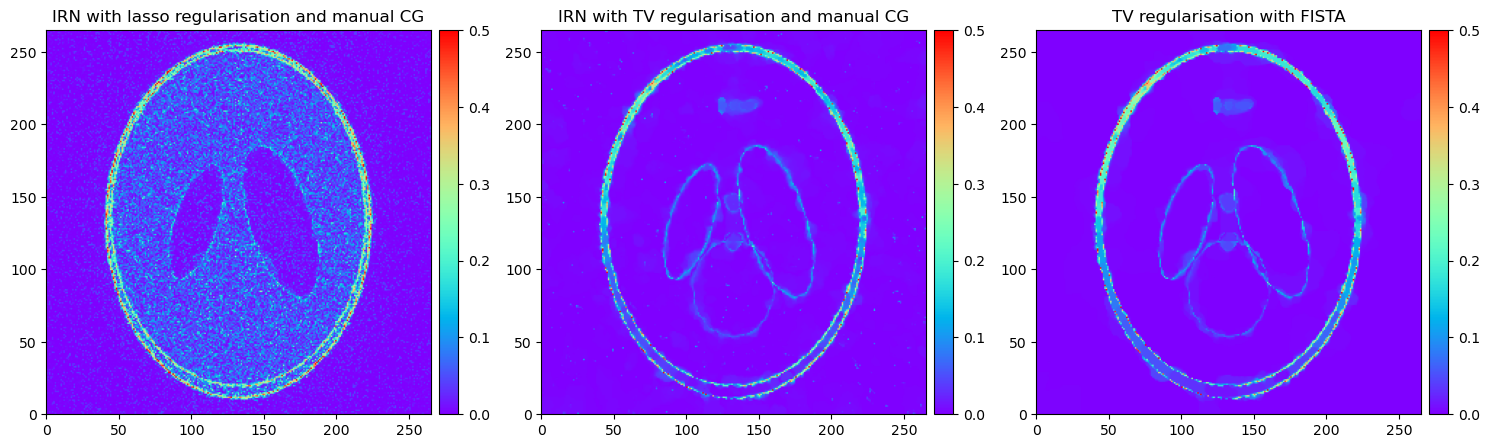

In [14]:
show2D([(phantom - lasso_cg).abs(), (phantom - tv_cg).abs(), (phantom - tv_fista).abs()], 
       ['IRN with lasso regularisation and manual CG', 'IRN with TV regularisation and manual CG', 'TV regularisation with FISTA'], 
       axis_labels=('', ''),
       cmap = 'rainbow',
       fix_range = (0, 0.5), 
       num_cols = 3)

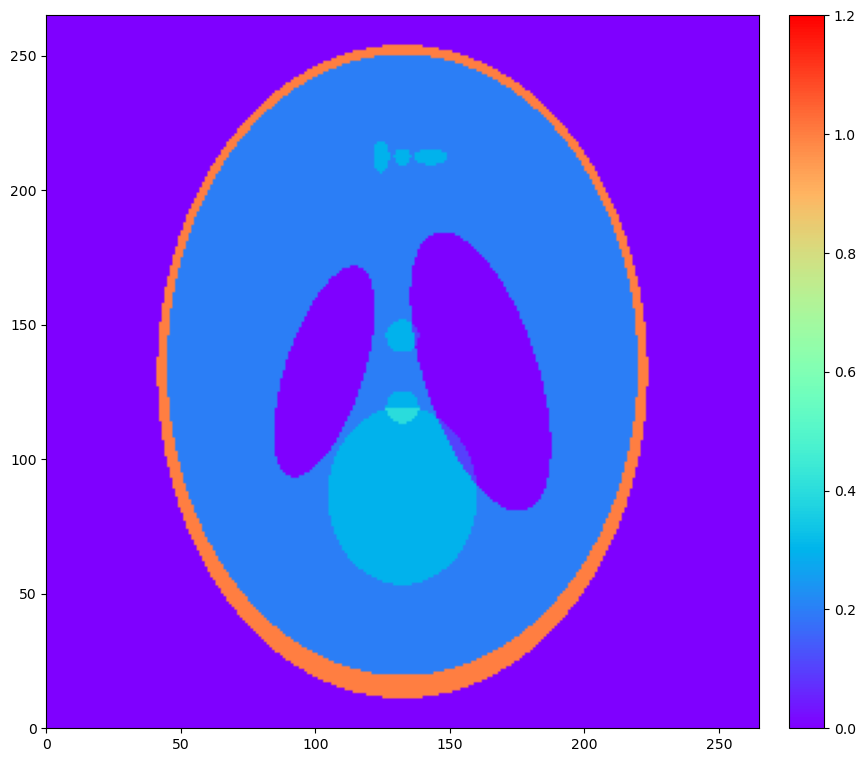

In [ ]:
show2D([phantom], 
       axis_labels=('', ''),
       cmap = 'rainbow',
       fix_range = (0, 1.2))

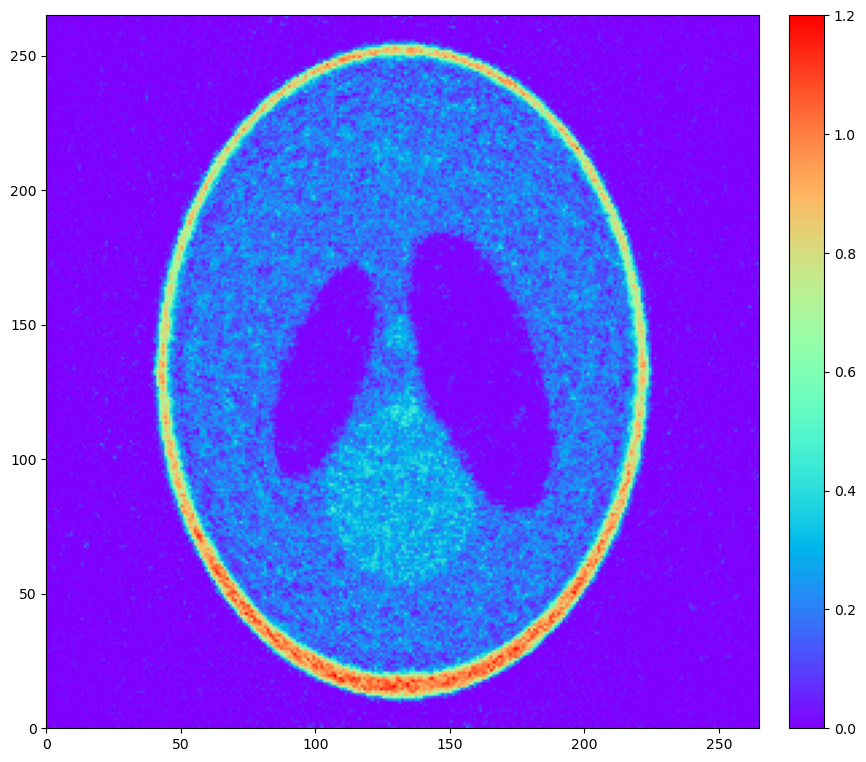

In [ ]:
show2D([lasso_cgls.abs()],
       axis_labels=('', ''),
       cmap = 'rainbow',
       fix_range = (0, 1.2))

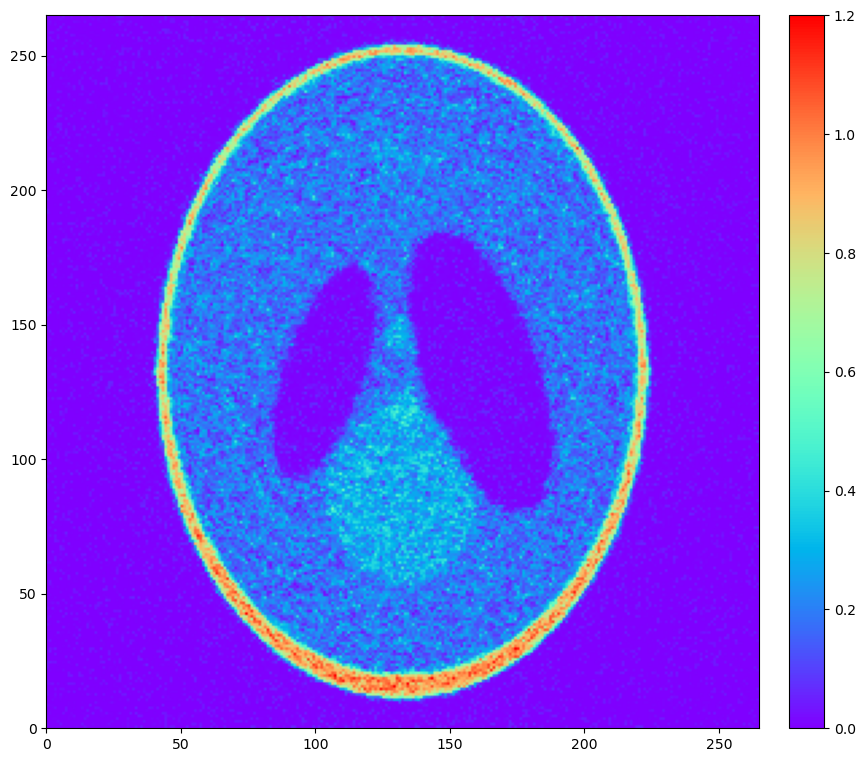

In [ ]:
show2D([lasso_cg.abs()], 
       axis_labels=('', ''),
       cmap = 'rainbow',
       fix_range = (0, 1.2))

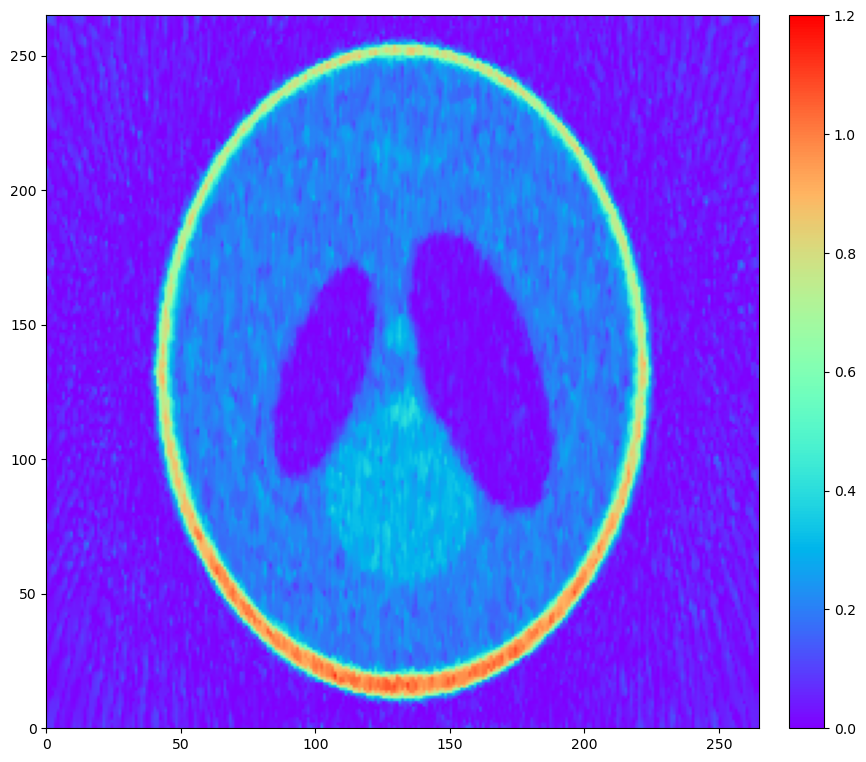

In [ ]:
show2D([tv_cgls_sol.abs()], 
       axis_labels=('', ''),
       cmap = 'rainbow',
       fix_range = (0, 1.2))

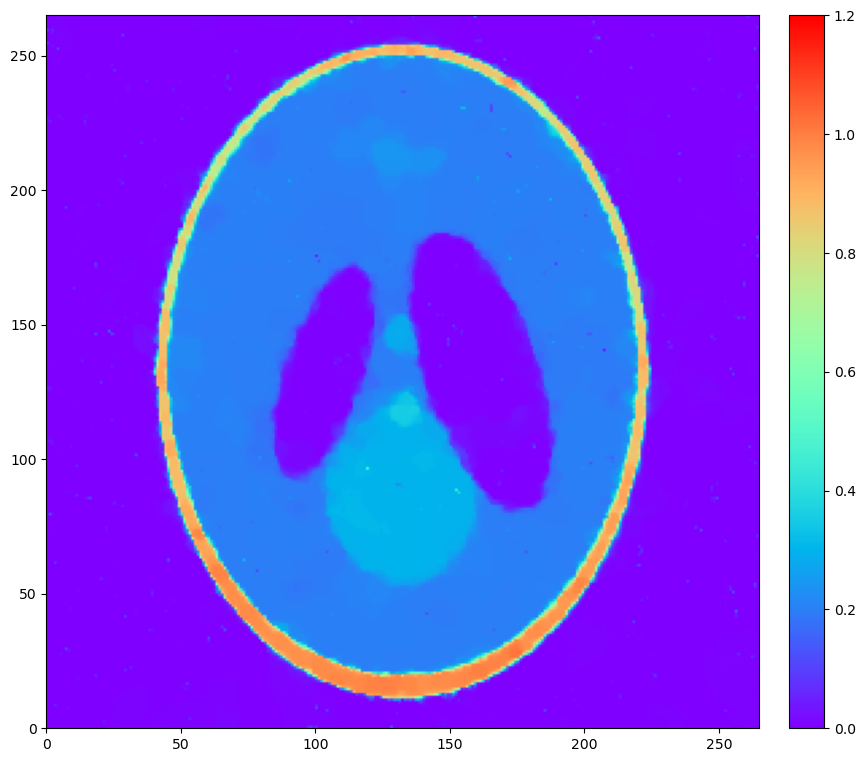

In [ ]:
show2D([tv_cg.abs()],  
       axis_labels=('', ''),
       cmap = 'rainbow',
       fix_range = (0, 1.2))

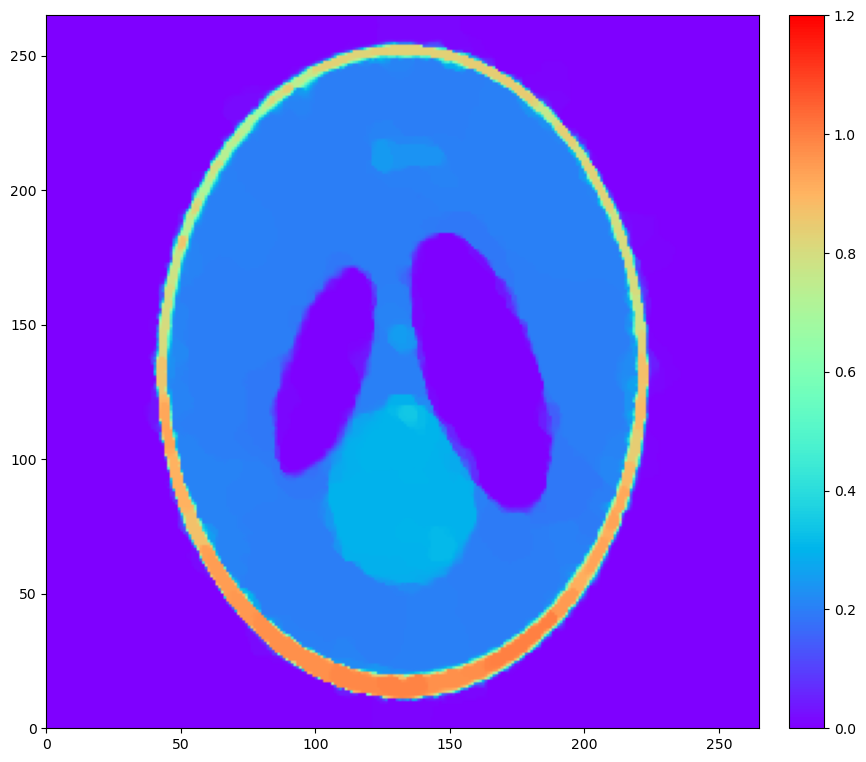

In [ ]:
show2D([tv_fista.abs()], 
       axis_labels=('', ''),
       cmap = 'rainbow',
       fix_range = (0, 1.2))